## Moduli

In [31]:
import pandas as pd
import ast
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

## Seed-ovi

In [2]:
RANDOM_STATE = 7

## Pretprocesiranje skupa podataka

In [3]:
data = pd.read_csv('data/protein_data.csv')

In [4]:
data.head()

,accession,sequence,labels
0,P03265,MASREEEQRETTPERGRGAARRPPTMEDVSSPSPSPPPPRAPPKKR...,"[-5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -..."
1,P49913,MKTQRDGHSLGRWSLVLLLLGLVMPLAIIAQVLSYKEAVLRAIDGI...,"[-5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -..."
2,P03045,MDAQTRRRERRAEKQAQWKAANPLLVGVSAKPVNRPILSLNRKPKS...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,P00004,MGDVEKGKKIFVQKCAQCHTVEKGGKHKTGPNLHGLFGRKTGQAPG...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,P27695,MPKRGKKGAVAEDGDELRTEPEAKKSKTAAKKNDKEAAGEGPALYE...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


In [5]:
data.dtypes

accession    str
sequence     str
labels       str
dtype: object

In [6]:
data['labels'] = data['labels'].apply(ast.literal_eval)
#data.dtypes

Ideja i za konvolutivne i za rekurentne neuronske mreže je da našu sekvencu prvo embed-ujemo (**TODO** kako se ovo prevodi). Za to nam je potrebna fiksna dužina sekvence, pa analiziramo šta da postavimo za tu dužinu.

In [7]:
print("Max length: ", data['sequence'].str.len().max())
print("Average length: ", data['sequence'].str.len().mean())

Max length:  34350
Average length:  584.8510638297872


Vidimo da su neki stringovi vrlo dugacki, ali većina je zapravo relativno mala.

In [8]:
data['sequence_length'] = data['sequence'].str.len()
print("Number of proteins having length over 5000: ", data[data['sequence_length'] >= 5000].shape[0])
print("Number of proteins having length over 2000: ", data[data['sequence_length'] >= 2000].shape[0])
print("Number of proteins having length over 1000: ", data[data['sequence_length'] >= 1000].shape[0])
print("Number of proteins having length over 500: ", data[data['sequence_length'] >= 500].shape[0])
data[data['sequence_length'] >= 5000]

Number of proteins having length over 5000:  5
Number of proteins having length over 2000:  109
Number of proteins having length over 1000:  434
Number of proteins having length over 500:  1340


,accession,sequence,labels,sequence_length
52,Q8WZ42,MTTQAPTFTQPLQSVVVLEGSTATFEAHISGFPVPEVSWFRDGQVI...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",34350
1124,O14686,MDSQKLAGEDKDSEPAADGPAASEDPSATESDLPNPHVGEVSVLSS...,"[-5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -...",5537
1948,P0C6X7,MESLVLGVNEKTHVQLSLPVLQVRDVLVRGFGDSVEEALSEAREHL...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, ...",7073
1949,P0DTD1,MESLVPGFNEKTHVQLSLPVLQVRDVLVRGFGDSVEEVLSEARQHL...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",7096
3305,P11716,MGDGGEGEDEVQFLRTDDEVVLQCSATVLKEQLKLCLAAEGFGNRL...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",5037


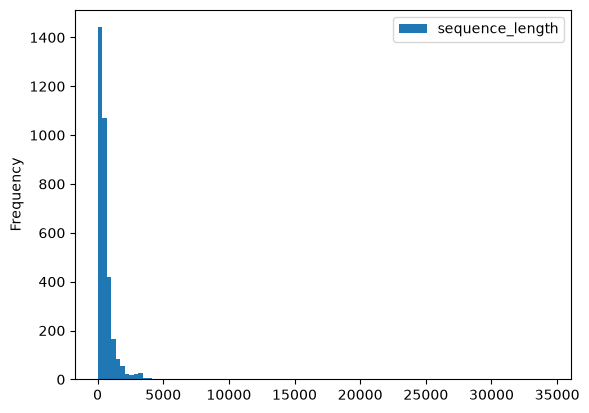

In [9]:
data.plot.hist(bins=100)
plt.show()

Nemamo mnogo proteina dužine veće od $1000$. Nema smisla vršiti padding do maksimalne dužine, pošto će većina instanci imati padding barem $30$ puta duži od njihove prave dužine. Ovaj problem mogli bismo da rešimo izbacivanjem velikih instanci iz skupa podataka, ali mi zaista želimo da smo u mogućnosti da analiziramo i velike proteine. Srećom, struktura naših modela nam omogućava da ovo jednostavno rešimo. Naime, jedan dugačak protein možemo deliti na više manjih, nad kojima model može vršiti predviđanja. Jedini problem koji ovde nastaje je što model gubi na izražajnosti kad su u pitanju dugački proteini, jer se smanjuje kontekst.

In [10]:
MAX_PROTEIN_LENGTH = 1000

RESIDUE_LIST  = list("ACDEFGHIKLMNPQRSTVWY")

def get_residue_position(c):
    for j in range(len(RESIDUE_LIST)):
        if c == RESIDUE_LIST[j]:
            # ostavljamo 0 za padding
            return j + 1
    # nestandardne aminokiseline dobijaju zajednicku vrednost
    return len(RESIDUE_LIST) + 1

def tokenize_sequences(sequences):
    result = []
    for sequence in sequences:
        tokenized_seq = []
        for c in sequence:
            tokenized_seq.append(get_residue_position(c.upper()))
        result.append(tokenized_seq)
    return result
    
tokenized_sequences = tokenize_sequences(data['sequence'])
#print(len(tokenized_sequences))
#print(tokenized_sequences[:5])

In [20]:
def split_and_pad(sequence_list, label_list):
    """
    Imamo dva zadatka:
    1) Podeliti predugacke proteine
    2) Pad-ovati prekratke proteine
    """
    
    seq_res = []
    lab_res = []
    
    cnt_new_splits = 0
    
    for i in range(len(sequence_list)):
        sequence = sequence_list[i]
        labels = label_list[i]
        
        # deljenje
        for j in range(len(sequence)):
            l = j*MAX_PROTEIN_LENGTH
            r = j*MAX_PROTEIN_LENGTH + MAX_PROTEIN_LENGTH
            
            if l >= len(sequence):
                break
            
            if j >= 1:
                cnt_new_splits += 1
            
            r = min(r, len(sequence))
            
            seq_split = sequence[l:r]
            lab_split = labels[l:r]
            
            start_len = len(seq_split)
            
            # padding
            for k in range(start_len, MAX_PROTEIN_LENGTH):
                # mozemo kao label dati istu "neutvrdjenu vrednost"
                # svakako to ne racunamo u funkciji greske
                seq_split.append(0)
                lab_split.append(-5)
            
            seq_res.append(seq_split)
            lab_res.append(lab_split)
            
    print("Generated ", cnt_new_splits, " new splits")
    
    return seq_res, lab_res
    
    
seq_train_val, seq_test, labels_train_val, labels_test = train_test_split(tokenized_sequences, data['labels'].tolist(), random_state = RANDOM_STATE, test_size = 0.2)
seq_train, seq_val, labels_train, labels_val = train_test_split(seq_train_val, labels_train_val, random_state = RANDOM_STATE, test_size = 0.2)

# TODO: proveriti ovo !!!!!!

seq_train, labels_train = split_and_pad(seq_train, labels_train)
seq_val, labels_val = split_and_pad(seq_val, labels_val)
seq_test, labels_test = split_and_pad(seq_test, labels_test)

Generated  400  new splits
Generated  93  new splits
Generated  146  new splits


In [28]:
BATCH_SIZE = 64

train_loader = DataLoader(list(zip(seq_train, labels_train)), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(list(zip(seq_val, labels_val)), batch_size=BATCH_SIZE)
test_loader = DataLoader(list(zip(seq_test, labels_test)), batch_size=BATCH_SIZE)